# Notebook 13 – Model Explainability

**Dataset:** Online Retail transactions (data.csv)

**Problem:** Predict whether an order is **international** (non-UK, ~11% of data) using quantity, price and time features.

We compare an **interpretable** model (Logistic Regression) with a **black-box** model (Gradient Boosting), then use several tools to look inside the black box.

**Installation (SHAP is an external library):**
```bash
pip install shap
```

## Setup: Load Data & Train Two Models

In [1]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\hemak\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
df = pd.read_csv('data.csv', encoding='latin1')
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].sample(8000, random_state=42)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Month'] = df['InvoiceDate'].dt.month
features = ['Quantity', 'UnitPrice', 'TotalPrice', 'Hour', 'DayOfWeek', 'Month']
X = df[features]
y = (df['Country'] != 'United Kingdom').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.7,
                                random_state=42).fit(X_train, y_train)

## 1. What is Model Explainability?
**Model explainability** is the ability to understand **why** a model makes the predictions it does — which features it relies on, and how they push a prediction up or down.

A prediction alone (e.g., "72% chance international") doesn't tell us *why*.

In [19]:
sample = X_test.iloc[[0]]
print(sample.T)
print("\nPredicted probability of international:", round(gb.predict_proba(sample)[0, 1], 3))
print("...but WHY? A probability alone doesn't say.")

            196155
Quantity     24.00
UnitPrice     2.55
TotalPrice   61.20
Hour         11.00
DayOfWeek     3.00
Month         5.00

Predicted probability of international: 0.248
...but WHY? A probability alone doesn't say.


## 2. Why Explainability?
- **Trust:** people act on predictions only if they understand them.
- **Debugging:** find features the model wrongly relies on (data leaks, IDs, bias).
- **Fairness & regulation:** some decisions must be explained (credit, hiring, medical).
- **Improvement:** knowing what drives predictions shows which features to improve.

**Performance tells us how *well* a model works, not *why* it works.**

In [20]:
for name, model in [('Logistic Regression', log_reg), ('Gradient Boosting', gb)]:
    print(f"{name}: test ROC-AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.3f}")
print("Scores alone can't tell us if the models rely on sensible features.")

Logistic Regression: test ROC-AUC = 0.635
Gradient Boosting: test ROC-AUC = 0.753
Scores alone can't tell us if the models rely on sensible features.


## 3. Interpretable vs Black-Box Models
- **Interpretable (white-box):** you can read the model directly. Logistic Regression has one coefficient per feature; a shallow Decision Tree shows its rules.
- **Black-box:** too many moving parts to read directly (e.g., 200 boosted trees, neural networks). Often more accurate, but needs explanation tools.

In [21]:
coefs = pd.Series(log_reg[-1].coef_[0], index=features).sort_values()
print("Logistic Regression coefficients:")
print(coefs.round(3))
print("\nGradient Boosting has", gb.n_estimators, "trees - no single set of coefficients to read.")

Logistic Regression coefficients:
Hour         -0.347
DayOfWeek    -0.145
Month        -0.062
TotalPrice    0.050
Quantity      0.078
UnitPrice     0.228
dtype: float64

Gradient Boosting has 200 trees - no single set of coefficients to read.


## 4. Feature Importance
Tree models report a built-in **feature importance**: how much each feature reduced impurity across all trees. It's quick, but has caveats — it is computed on the training data and tends to favor continuous features.

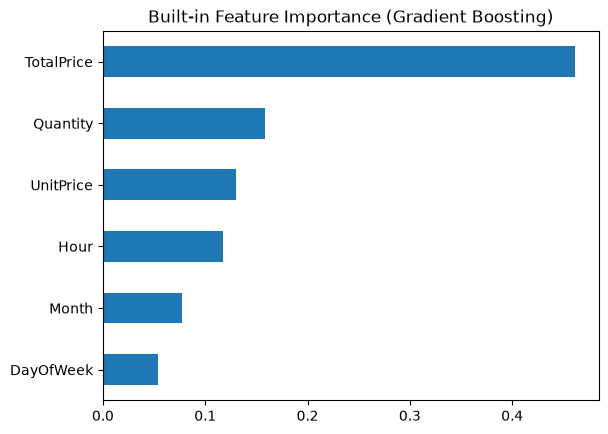

In [22]:
fi = pd.Series(gb.feature_importances_, index=features).sort_values()
fi.plot(kind='barh', title='Built-in Feature Importance (Gradient Boosting)')
plt.show()

## 5. Permutation Importance
Shuffle one feature at a time on the **test set** and measure how much the score drops. A big drop means the model relies heavily on that feature. It works for **any** model and reflects real held-out performance.

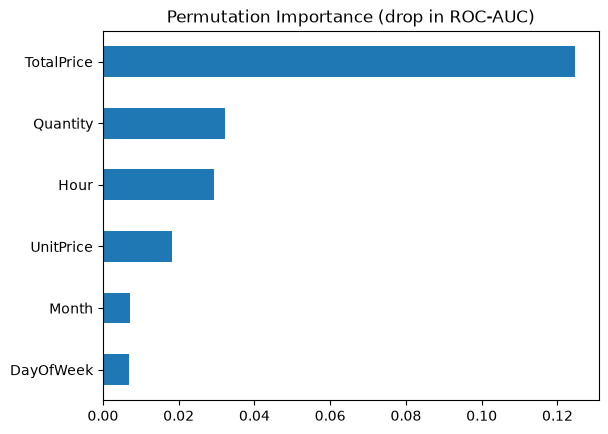

In [23]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(gb, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42)
perm_series = pd.Series(perm.importances_mean, index=features).sort_values()
perm_series.plot(kind='barh', title='Permutation Importance (drop in ROC-AUC)')
plt.show()

## 6. Partial Dependence – Introduction
A **partial dependence plot (PDP)** shows how the model's average prediction changes as **one feature varies**, with the other features averaged out. It reveals the *shape* of the relationship (rising, falling, threshold effects).

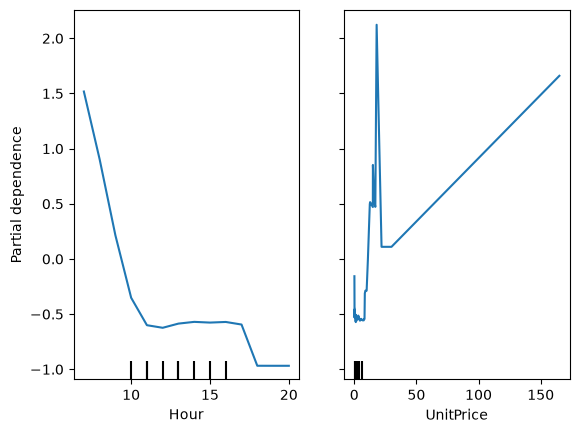

In [25]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(gb, X_test.astype(float), ['Hour', 'UnitPrice'])
plt.show()

## 7. SHAP – Introduction
**SHAP** (SHapley Additive exPlanations) assigns each feature a value showing **how much it pushed a prediction up or down** compared to the average prediction. SHAP values add up: *average prediction + sum of feature contributions = this prediction* (in log-odds for classifiers).

It gives both **local** (one prediction) and **global** (whole model) explanations.

In [26]:
import shap
explainer = shap.TreeExplainer(gb)
shap_values = explainer(X_test)     
print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (1600, 6)


## 8. Local Explanation
A **local explanation** explains **one individual prediction**. Here we pick an order the model flags as international and see which features pushed it there (red = pushes toward international, blue = pushes away).

Order features:
 Quantity       1.0
UnitPrice     18.0
TotalPrice    18.0
Hour           9.0
DayOfWeek      3.0
Month         10.0
Name: 379985, dtype: float64
Predicted probability: 0.874


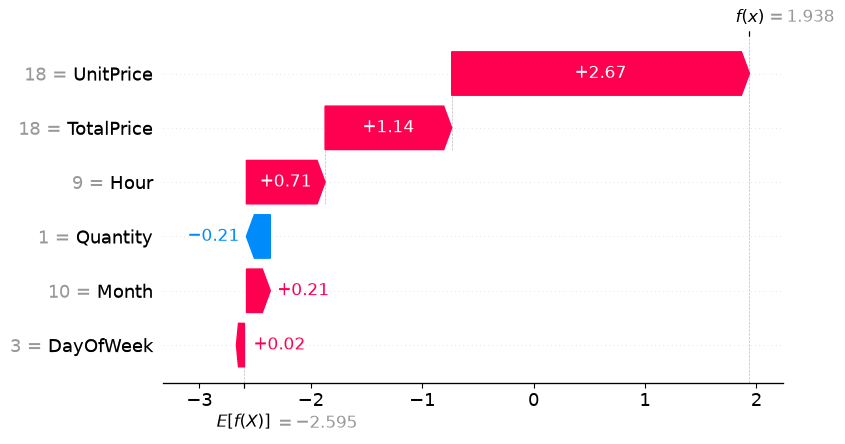

In [27]:
probs = gb.predict_proba(X_test)[:, 1]
idx = int(np.argmax(probs))      
print("Order features:\n", X_test.iloc[idx])
print("Predicted probability:", round(probs[idx], 3))
shap.plots.waterfall(shap_values[idx])

## 9. Global Explanation
A **global explanation** describes the model's behavior **overall** — which features matter most across all predictions. The bar chart shows the average size of each feature's SHAP value; the beeswarm shows direction too (does a high feature value push predictions up or down?).

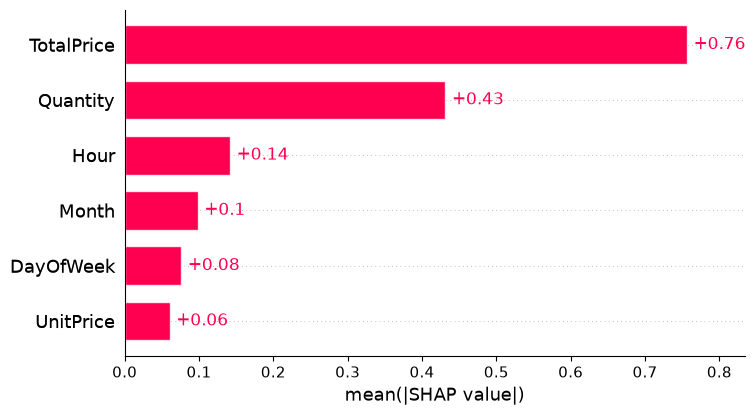

In [13]:
shap.plots.bar(shap_values)

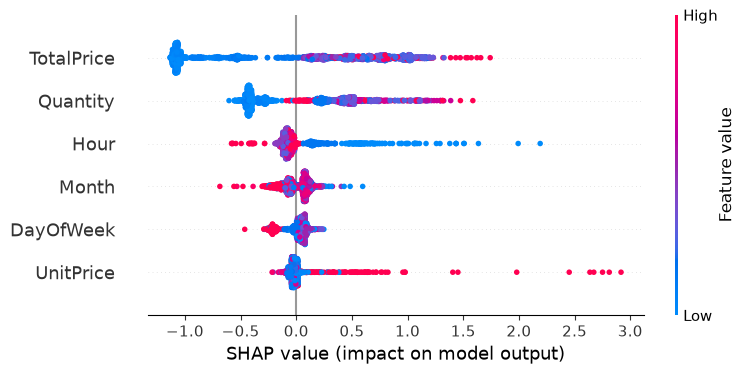

In [14]:
shap.plots.beeswarm(shap_values)

# Why Model Performance Alone Is Not Sufficient

Let's see a dangerous example. We add `CustomerID` as a feature — it looks harmless.

In [15]:
features_leak = features + ['CustomerID']
X_l = df[features_leak]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_l, y, test_size=0.2, random_state=42, stratify=y)
leaky = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.7,
                                   random_state=42).fit(Xl_train, yl_train)
print("Original model  ROC-AUC:", round(roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1]), 3))
print("Model + CustomerID ROC-AUC:", round(roc_auc_score(yl_test, leaky.predict_proba(Xl_test)[:, 1]), 3))

Original model  ROC-AUC: 0.753
Model + CustomerID ROC-AUC: 0.994


The score jumps to almost perfect. Looks amazing — **but why?** Permutation importance tells us:

In [16]:
perm2 = permutation_importance(leaky, Xl_test, yl_test, scoring='roc_auc', n_repeats=5, random_state=42)
pd.Series(perm2.importances_mean, index=features_leak).sort_values(ascending=False).round(3)

CustomerID    0.386
TotalPrice    0.001
Hour          0.001
Quantity      0.000
Month         0.000
DayOfWeek     0.000
UnitPrice     0.000
dtype: float64

The model relies almost entirely on `CustomerID`. Why would an ID predict country? Let's look at the share of international orders by **ID range**:

In [17]:
id_blocks = pd.cut(df['CustomerID'], [12000, 12500, 13000, 13500, 14000, 15000, 16000, 17000, 18500])
y.groupby(id_blocks, observed=True).mean().round(2)

CustomerID
(12000, 12500]    1.00
(12500, 13000]    0.60
(13000, 13500]    0.00
(13500, 14000]    0.03
(14000, 15000]    0.14
(15000, 16000]    0.00
(16000, 17000]    0.00
(17000, 18500]    0.01
Name: Country, dtype: float64

Customer IDs were **assigned in blocks that follow region** — IDs 12000–12500 are almost all international, while IDs above 13000 are overwhelmingly UK. So the ID *contains the answer*. Is the model just memorizing individual customers? Let's test on **customers it has never seen** (group split):

In [18]:
from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_l, y, groups=df['CustomerID']))
leaky_g = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.7,
                                     random_state=42).fit(X_l.iloc[train_idx], y.iloc[train_idx])
auc_new_customers = roc_auc_score(y.iloc[test_idx], leaky_g.predict_proba(X_l.iloc[test_idx])[:, 1])
print("ROC-AUC on NEW customers (with CustomerID):", round(auc_new_customers, 3))

ROC-AUC on NEW customers (with CustomerID): 0.965
